In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import gymnasium as gym
from typing import cast

from student_client import create_student_gym_env
from reinforce_utils import train_reinforce_discrete, sample_discrete_action

device = torch.device("cpu" if torch.cuda.is_available() else "cpu") 

In [3]:
env = create_student_gym_env(user_token='14S544O#BEiKzhK')
env.reset()

2026-02-27 16:12:02,445 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode 17323a3c-5ca9-4686-a43f-f6f11a4a0ef0
2026-02-27 16:12:03,315 - student_client.student_gym_env - INFO - Episode 17323a3c-5ca9-4686-a43f-f6f11a4a0ef0 reset successfully


(array([7.9649170e+02, 1.9425998e+04, 3.3586362e+02, 1.1214299e+03,
        3.7231919e-01, 1.3622965e+06, 3.9578174e+03, 0.0000000e+00,
        9.9023399e+00], dtype=float32),
 {'step': 0,
  'episode_id': '17323a3c-5ca9-4686-a43f-f6f11a4a0ef0',
  'terminated': False,
  'truncated': False})

In [4]:
observation_space = cast(gym.spaces.Box, env.observation_space)
action_space = cast(gym.spaces.Discrete, env.action_space)

observation_dim = observation_space.shape[0]
num_actions = action_space.n.item() 

print(f"State space size is: {observation_space}")
print(f"Action space size is: {action_space}")
print("Actions are: {" + ", ".join([str(a) for a in range(action_space.n)]) + "}")

print(f"Observation dim: {observation_dim}")
print(f"Num actions: {num_actions}")

State space size is: Box(-inf, inf, (9,), float32)
Action space size is: Discrete(3)
Actions are: {0, 1, 2}
Observation dim: 9
Num actions: 3


In [7]:
reinforce_policy_nn, episode_reward_list = train_reinforce_discrete(
    num_train_episodes=3,
    num_test_per_episode=1,
    max_episode_duration=10,
    learning_rate=0.005,
    device=device
)

# reinforce_policy_nn.layer1.weight

  0%|          | 0/3 [00:00<?, ?it/s]

Sampling one full episode


2026-02-27 16:16:04,802 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode eb215756-573f-4a4c-9987-f7fb624a1aba
2026-02-27 16:16:05,703 - student_client.student_gym_env - INFO - Episode eb215756-573f-4a4c-9987-f7fb624a1aba reset successfully


Start training for episode 1 / 3
loss: 1.0658141036401503e-13
Training done
Testing current pollicy


2026-02-27 16:16:22,266 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode 7352df41-e183-4b7c-b313-838752163e37
2026-02-27 16:16:23,139 - student_client.student_gym_env - INFO - Episode 7352df41-e183-4b7c-b313-838752163e37 reset successfully


...

2026-02-27 16:16:55,639 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode 9160cdef-d423-4499-b5ed-e5ca9fd7adde
2026-02-27 16:16:56,673 - student_client.student_gym_env - INFO - Episode 9160cdef-d423-4499-b5ed-e5ca9fd7adde reset successfully


Sampling one full episode


2026-02-27 16:17:12,560 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode e9df051a-f084-4958-9bd3-e117a5e69a73
2026-02-27 16:17:13,891 - student_client.student_gym_env - INFO - Episode e9df051a-f084-4958-9bd3-e117a5e69a73 reset successfully


Start training for episode 3 / 3
loss: 3.552713678800501e-14
Training done
Testing current pollicy


2026-02-27 16:17:30,094 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode 2d0002d1-94f8-4e7c-8d28-45a45accdbd4
2026-02-27 16:17:31,411 - student_client.student_gym_env - INFO - Episode 2d0002d1-94f8-4e7c-8d28-45a45accdbd4 reset successfully


In [8]:
# Initialize data collection arrays
env = create_student_gym_env(user_token='14S544O#BEiKzhK')
obs, info = env.reset()
observations = [obs]
actions = []
rewards = []
total_timesteps = 0

for step in range(50):

    # Choose a random action (0=do nothing, 1=repair, 2=sell)
    print(observations[-1].shape)
    if len(observations[-1].shape) > 1:
        # action = reinforce_policy_nn(observations[-1][-1])
        action, _ = sample_discrete_action(reinforce_policy_nn, observations[-1][-1], device)
    else:
        action, _ = sample_discrete_action(reinforce_policy_nn, observations[-1], device)

    
    #print(action)

    # Take step in environment
    obs_result, reward, terminated, truncated, info = env.step(
        action=action,
    )
    #print(obs_result)

    #print(f'obs_result: {obs_result.shape}')

    observations.append(obs_result)
    actions.append(action)

    rewards.append(reward)

    # Update total timesteps - server advances by step_size but returns only final observation
    total_timesteps = info['step']

    # Print progress every step
    if step % 1 == 0:
        print(f" Step {total_timesteps}: Reward={reward:.2f}, Total={sum(rewards):.2f}")

    # Check if episode ended
    if terminated or truncated:
        print(f"🏁 Episode ended at step {total_timesteps} with reward={reward:.2f}")
        break


# Print summary statistics
total_reward = sum(rewards)
print(f"\n Episode Summary:")
print(f"   Total Steps: {len(actions)}")
print(f"   Total Reward: {total_reward:.2f}")
print(f"   Actions Taken: {len([a for a in actions if a == 1])} repairs, {len([a for a in actions if a == 2])} sell")

2026-02-27 16:18:25,507 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode 9db4f64e-b870-4ce9-96c7-1ef457e74360
2026-02-27 16:18:26,401 - student_client.student_gym_env - INFO - Episode 9db4f64e-b870-4ce9-96c7-1ef457e74360 reset successfully


(9,)
 Step 10: Reward=-524.59, Total=-524.59
(10, 9)
 Step 20: Reward=-518.12, Total=-1042.72
(10, 9)
 Step 30: Reward=-518.90, Total=-1561.61
(10, 9)
 Step 40: Reward=-521.30, Total=-2082.92
(10, 9)
 Step 50: Reward=-532.16, Total=-2615.07
(10, 9)
 Step 60: Reward=-529.04, Total=-3144.12
(10, 9)
 Step 70: Reward=-518.76, Total=-3662.88
(10, 9)
 Step 80: Reward=-517.40, Total=-4180.28
(10, 9)
 Step 90: Reward=-526.53, Total=-4706.81
(10, 9)
 Step 100: Reward=-499.50, Total=-5206.31
(10, 9)
 Step 110: Reward=-497.44, Total=-5703.76
(10, 9)
 Step 120: Reward=-547.07, Total=-6250.83
(10, 9)
 Step 130: Reward=-506.21, Total=-6757.03
(10, 9)
 Step 140: Reward=-506.43, Total=-7263.46
(10, 9)
 Step 150: Reward=-525.83, Total=-7789.29
(10, 9)
 Step 160: Reward=-523.70, Total=-8312.99
(10, 9)
 Step 170: Reward=-520.45, Total=-8833.44
(10, 9)
 Step 180: Reward=-541.80, Total=-9375.24
(10, 9)
 Step 190: Reward=-527.19, Total=-9902.43
(10, 9)
 Step 200: Reward=-518.13, Total=-10420.56
(10, 9)
 Ste

⚠️ Warning: number of actions (50) != number of batches (51). Truncating to the shorter length.


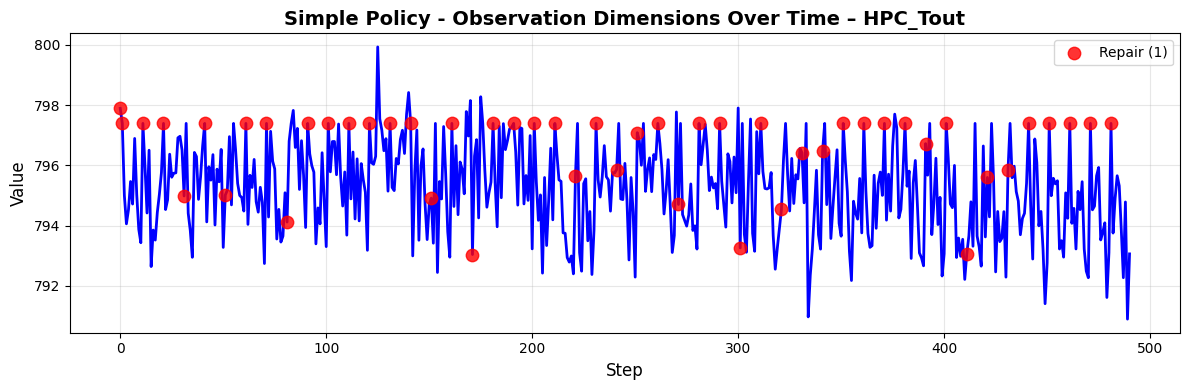

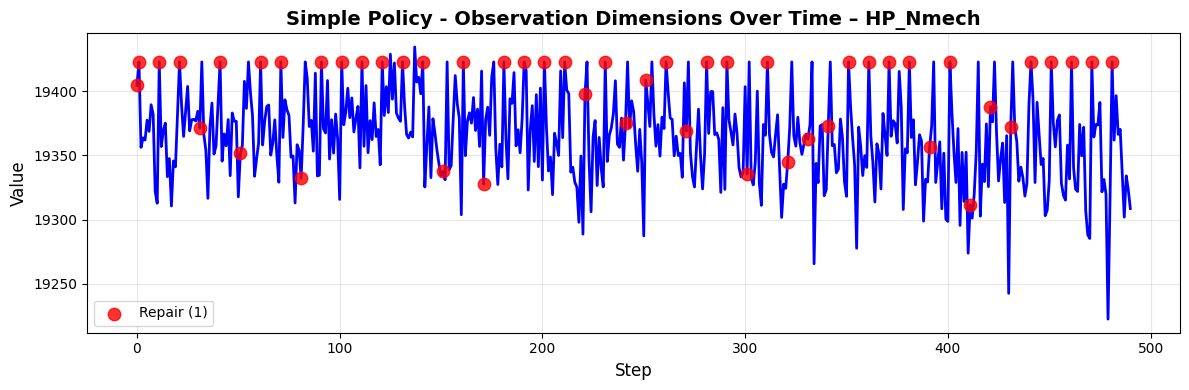

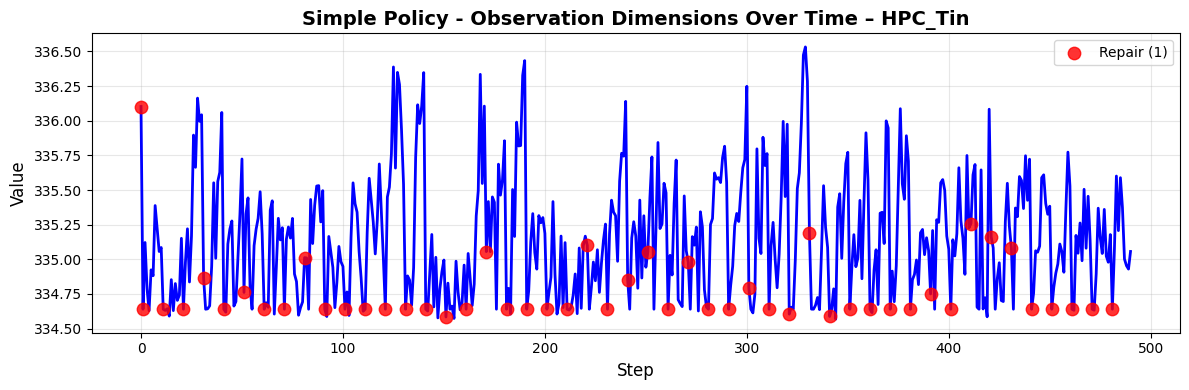

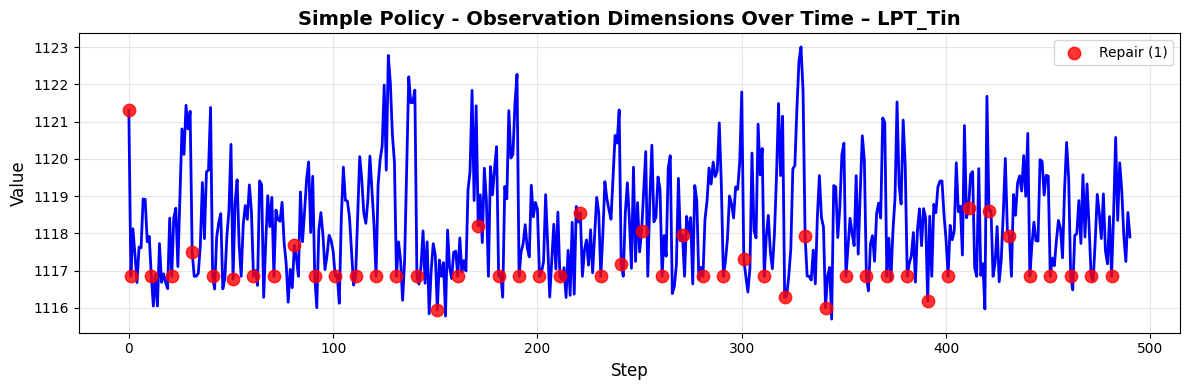

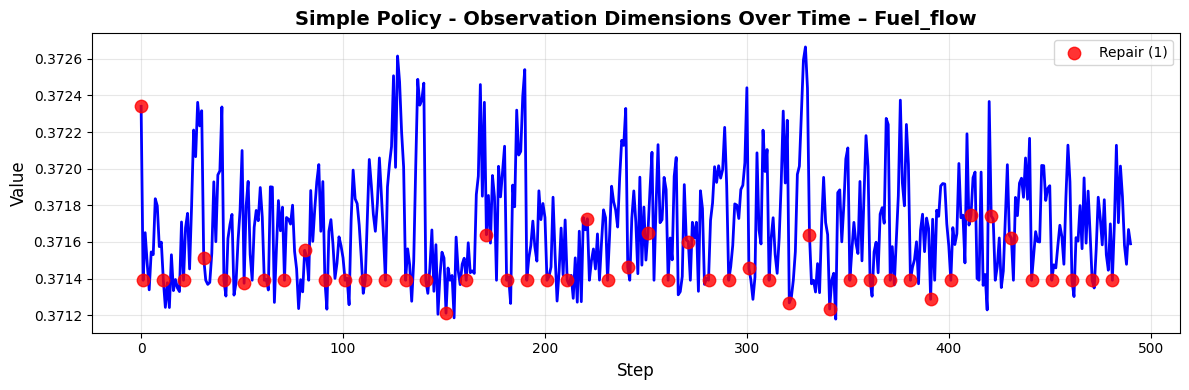

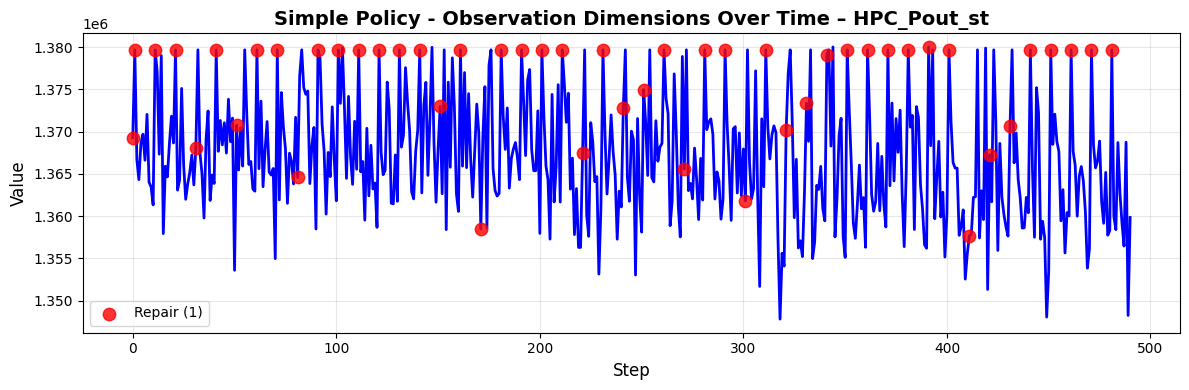

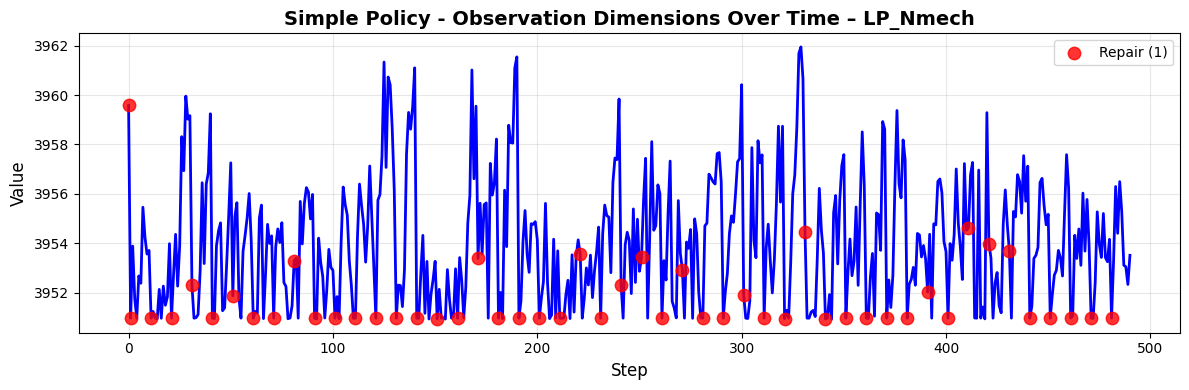

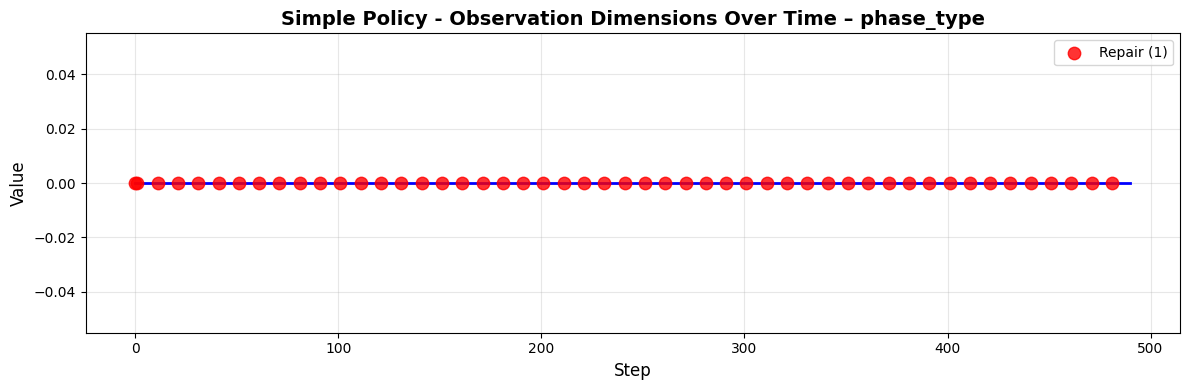

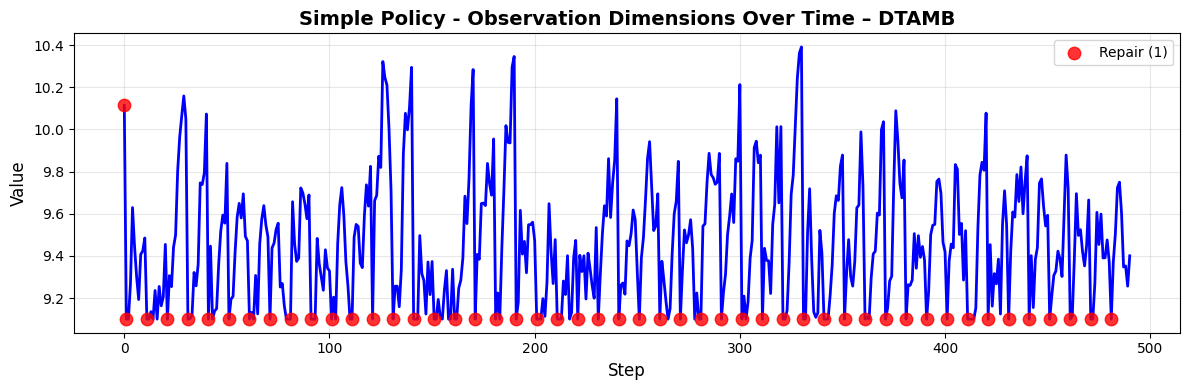

In [9]:
from student_client.plotting import plot_observations


plot_observations(
        observations=observations,
        actions=actions,
        title="Simple Policy - Observation Dimensions Over Time"
    )

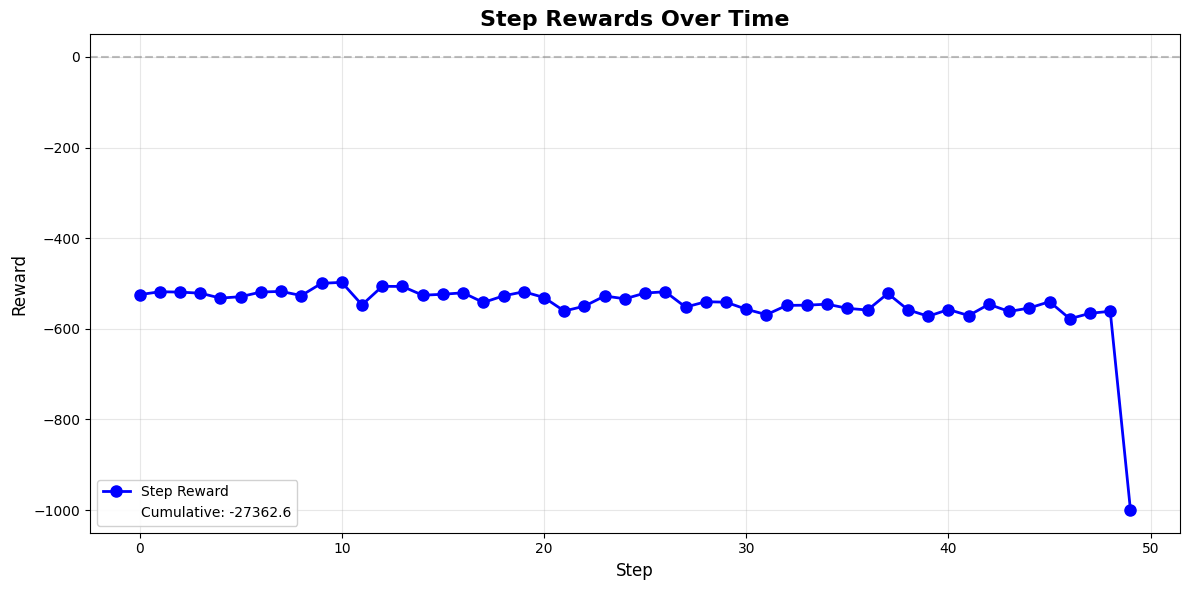

📊 Reward Statistics:
   Total Steps: 50
   Total Reward: -27362.64
   Average Reward: -547.25
   Max Reward: -497.44
   Min Reward: -1000.00


In [10]:
from student_client.plotting import plot_rewards

plot_rewards(rewards=rewards)